In [5]:
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter
import emoji

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

# Modelagem
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [6]:

# Downloads necessários
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('rslp', quiet=True)

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [7]:

print("="*70)
print("📊 ANÁLISE DE DADOS NÃO ESTRUTURADOS - INSTAGRAM")
print("="*70)

df = pd.read_csv('dados/trusted/dataset_comentarios_com_posts.csv')
print(f"\n✅ Dataset carregado: {len(df)} linhas")
print(f"📋 Colunas: {list(df.columns)}")

# Trabalhar com os comentários
textos_originais = df['comment_text'].dropna().tolist()
print(f"\n💬 Total de comentários para análise: {len(textos_originais)}")



📊 ANÁLISE DE DADOS NÃO ESTRUTURADOS - INSTAGRAM

✅ Dataset carregado: 56 linhas
📋 Colunas: ['post_url', 'post_caption', 'post_owner_full_name', 'post_owner_username', 'post_likes_count', 'post_comments_count', 'post_timestamp', 'post_first_comment', 'comment_id', 'comment_text', 'comment_timestamp', 'comment_owner_profile_pic']

💬 Total de comentários para análise: 56


In [8]:

print("\n" + "="*70)
print("🧹 ETAPA 1: LIMPEZA BÁSICA")
print("="*70)

def limpar_basico(texto):
    """Remove pontuações e quebras de linha, mantém emojis temporariamente"""
    if pd.isna(texto):
        return ""
    
    # Converter para string
    texto = str(texto)
    
    # Substituir quebras de linha por espaço
    texto = texto.replace('\n', ' ').replace('\r', ' ')
    
    # Remover pontuações (mas manter emojis)
    # Remove apenas pontuação ASCII
    texto = re.sub(r'[^\w\s\U0001F300-\U0001F9FF]', ' ', texto)
    
    # Remove espaços múltiplos
    texto = ' '.join(texto.split())
    
    return texto

def remover_acentos(texto):
    """Remove acentuação"""
    nfkd = unicodedata.normalize('NFKD', texto)
    return ''.join([c for c in nfkd if not unicodedata.combining(c)])

# Aplicar limpeza básica
textos_limpos = [limpar_basico(t) for t in textos_originais]
textos_limpos = [t.lower() for t in textos_limpos]  # Minúsculas
textos_limpos = [remover_acentos(t) for t in textos_limpos]  # Sem acentos

print(f"✅ Limpeza básica concluída")
print(f"\nExemplo de transformação:")
print(f"Original: {textos_originais[0][:80]}")
print(f"Limpo: {textos_limpos[0][:80]}")



🧹 ETAPA 1: LIMPEZA BÁSICA
✅ Limpeza básica concluída

Exemplo de transformação:
Original: Ameeiiii
Limpo: ameeiiii



😊 ETAPA 2: ANÁLISE DETALHADA DE EMOJIS

📊 ESTATÍSTICAS DE EMOJIS:
   • Total de emojis: 83
   • Emojis únicos/diferentes: 11
   • Comentários com emoji: 33 (58.9%)
   • Média de emojis por comentário: 1.48
   • Total de palavras: 243
   • Proporção emojis/palavras: 0.342
   • Média de emojis a cada X palavras: 1 emoji a cada 2.9 palavras

🏆 TOP 10 EMOJIS MAIS USADOS:
   1. 😍 - 47 vezes (56.6%)
   2. 😂 - 13 vezes (15.7%)
   3. 👏 - 12 vezes (14.5%)
   4. 🔥 - 3 vezes (3.6%)
   5. 🏻 - 2 vezes (2.4%)
   6. 🥲 - 1 vezes (1.2%)
   7. 🙏 - 1 vezes (1.2%)
   8. 🎊 - 1 vezes (1.2%)
   9. 🙌 - 1 vezes (1.2%)
   10. 🙋 - 1 vezes (1.2%)


C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 128525 (\N{SMILING FACE WITH HEART-SHAPED EYES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 128514 (\N{FACE WITH TEARS OF JOY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 127995 (\N{EMOJI MODIFIER FITZPATRICK TYPE-1-2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ivanm\AppData\Local\Temp\ipykernel_34144\795663696.py:74: UserWarning: Glyph 129394 (\N{SMILING FACE WITH TEAR}) missing from font(


✅ Gráfico salvo em: dados/results/analise_emojis.png


C:\Users\ivanm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128525 (\N{SMILING FACE WITH HEART-SHAPED EYES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ivanm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128514 (\N{FACE WITH TEARS OF JOY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ivanm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ivanm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\lo

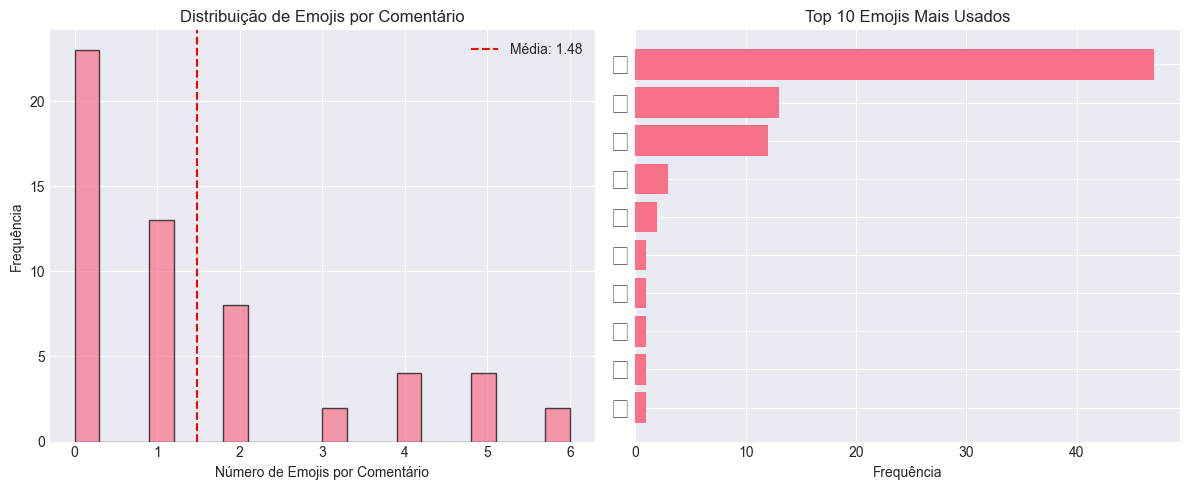

In [9]:

print("\n" + "="*70)
print("😊 ETAPA 2: ANÁLISE DETALHADA DE EMOJIS")
print("="*70)

def extrair_emojis(texto):
    """Extrai todos os emojis de um texto"""
    return [c for c in texto if c in emoji.EMOJI_DATA]

def contar_palavras(texto):
    """Conta palavras (sem emojis)"""
    texto_sem_emoji = ''.join([c for c in texto if c not in emoji.EMOJI_DATA])
    return len(texto_sem_emoji.split())

# Análise de emojis
emojis_por_comentario = [extrair_emojis(t) for t in textos_limpos]
todos_emojis = [e for lista in emojis_por_comentario for e in lista]

# Estatísticas
comentarios_com_emoji = sum(1 for e in emojis_por_comentario if len(e) > 0)
total_emojis = len(todos_emojis)
emojis_unicos = len(set(todos_emojis))

# Emojis mais usados
emoji_counter = Counter(todos_emojis)
top_emojis = emoji_counter.most_common(20)

# Palavras vs Emojis
total_palavras = sum(contar_palavras(t) for t in textos_limpos)
palavras_por_comentario = [contar_palavras(t) for t in textos_limpos]
emojis_contagem = [len(e) for e in emojis_por_comentario]

# Média de emojis por palavra
comentarios_com_palavras = [i for i, p in enumerate(palavras_por_comentario) if p > 0]
emojis_por_palavra = [
    emojis_contagem[i] / palavras_por_comentario[i] 
    for i in comentarios_com_palavras
]

print(f"\n📊 ESTATÍSTICAS DE EMOJIS:")
print(f"   • Total de emojis: {total_emojis}")
print(f"   • Emojis únicos/diferentes: {emojis_unicos}")
print(f"   • Comentários com emoji: {comentarios_com_emoji} ({comentarios_com_emoji/len(textos_limpos)*100:.1f}%)")
print(f"   • Média de emojis por comentário: {np.mean(emojis_contagem):.2f}")
print(f"   • Total de palavras: {total_palavras}")
print(f"   • Proporção emojis/palavras: {total_emojis/total_palavras:.3f}")
print(f"   • Média de emojis a cada X palavras: 1 emoji a cada {total_palavras/total_emojis:.1f} palavras")

print(f"\n🏆 TOP 10 EMOJIS MAIS USADOS:")
for i, (emoji_char, count) in enumerate(top_emojis[:10], 1):
    porcentagem = (count / total_emojis) * 100
    print(f"   {i}. {emoji_char} - {count} vezes ({porcentagem:.1f}%)")

# Visualização - Distribuição de emojis por comentário
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(emojis_contagem, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Número de Emojis por Comentário')
plt.ylabel('Frequência')
plt.title('Distribuição de Emojis por Comentário')
plt.axvline(np.mean(emojis_contagem), color='red', linestyle='--', 
            label=f'Média: {np.mean(emojis_contagem):.2f}')
plt.legend()

plt.subplot(1, 2, 2)
top_10_emojis = [e[0] for e in top_emojis[:10]]
top_10_counts = [e[1] for e in top_emojis[:10]]
plt.barh(range(len(top_10_emojis)), top_10_counts)
plt.yticks(range(len(top_10_emojis)), top_10_emojis, fontsize=20)
plt.xlabel('Frequência')
plt.title('Top 10 Emojis Mais Usados')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('dados/results/analise_emojis.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico salvo em: dados/results/analise_emojis.png")

# Salvar análise detalhada de emojis
df_emojis = pd.DataFrame({
    'emoji': [e[0] for e in top_emojis],
    'quantidade': [e[1] for e in top_emojis],
    'porcentagem': [(e[1]/total_emojis)*100 for e in top_emojis]
})
df_emojis.to_csv('dados/results/analise_emojis_detalhada.csv', index=False)


In [10]:

print("\n" + "="*70)
print("🗑️ ETAPA 3: REMOÇÃO DE EMOJIS E NÚMEROS")
print("="*70)

def remover_emojis_numeros(texto):
    """Remove emojis e números"""
    # Remover emojis
    texto = ''.join([c for c in texto if c not in emoji.EMOJI_DATA])
    # Remover números
    texto = re.sub(r'\d+', '', texto)
    # Limpar espaços extras
    texto = ' '.join(texto.split())
    return texto

textos_sem_emoji = [remover_emojis_numeros(t) for t in textos_limpos]

print(f"✅ Emojis e números removidos")
print(f"\nExemplo:")
print(f"Com emoji: {textos_limpos[1][:80]}")
print(f"Sem emoji: {textos_sem_emoji[1][:80]}")



🗑️ ETAPA 3: REMOÇÃO DE EMOJIS E NÚMEROS
✅ Emojis e números removidos

Exemplo:
Com emoji: 😂😂😂😂😂😂
Sem emoji: 


In [11]:

print("\n" + "="*70)
print("✂️ ETAPA 4: TOKENIZAÇÃO")
print("="*70)

def tokenizar(texto):
    """Divide texto em palavras (tokens)"""
    try:
        return word_tokenize(texto, language='portuguese')
    except:
        return texto.split()

textos_tokenizados = [tokenizar(t) for t in textos_sem_emoji]

print(f"✅ Tokenização concluída")
print(f"\nExemplo:")
print(f"Texto: {textos_sem_emoji[10]}")
print(f"Tokens: {textos_tokenizados[10]}")
print(f"\n📊 Média de tokens por comentário: {np.mean([len(t) for t in textos_tokenizados]):.1f}")



✂️ ETAPA 4: TOKENIZAÇÃO
✅ Tokenização concluída

Exemplo:
Texto: parabens meu bem voce merece o mundo
Tokens: ['parabens', 'meu', 'bem', 'voce', 'merece', 'o', 'mundo']

📊 Média de tokens por comentário: 4.3


In [12]:

print("\n" + "="*70)
print("🚫 ETAPA 5: REMOÇÃO DE STOPWORDS")
print("="*70)

def remover_stopwords(tokens):
    """Remove palavras sem significado analítico"""
    stop_words = set(stopwords.words('portuguese'))
    
    # Adicionar stopwords customizadas do contexto de estética
    stop_words.update([
        'pra', 'pro', 'ne', 'ta', 'to', 'la', 'ai', 'mt', 'tbm',
        'kkk', 'kkkk', 'kkkkk', 'rs', 'rsrs', 'haha', 'rsrsrs'
    ])
    
    return [palavra for palavra in tokens 
            if palavra not in stop_words and len(palavra) > 2]

textos_sem_stopwords = [remover_stopwords(t) for t in textos_tokenizados]

print(f"✅ Stopwords removidas")
print(f"\nExemplo:")
print(f"Com stopwords: {textos_tokenizados[10]}")
print(f"Sem stopwords: {textos_sem_stopwords[10]}")



🚫 ETAPA 5: REMOÇÃO DE STOPWORDS
✅ Stopwords removidas

Exemplo:
Com stopwords: ['parabens', 'meu', 'bem', 'voce', 'merece', 'o', 'mundo']
Sem stopwords: ['parabens', 'bem', 'voce', 'merece', 'mundo']


In [13]:

print("\n" + "="*70)
print("🌱 ETAPA 6: LEMATIZAÇÃO/STEMMING")
print("="*70)

def lematizar(tokens):
    """Reduz palavras à forma base"""
    stemmer = RSLPStemmer()
    return [stemmer.stem(palavra) for palavra in tokens]

textos_lematizados = [lematizar(t) for t in textos_sem_stopwords]

print(f"✅ Lematização concluída")
print(f"\nExemplo:")
print(f"Sem lematizar: {textos_sem_stopwords[10]}")
print(f"Lematizado: {textos_lematizados[10]}")

# Preparar textos para modelagem (juntar tokens)
textos_processados = [' '.join(tokens) for tokens in textos_lematizados]

# Salvar dataset processado
df_processado = df.copy()
df_processado['comment_text_clean'] = textos_sem_emoji
df_processado['comment_text_tokens'] = [' '.join(t) for t in textos_tokenizados]
df_processado['comment_text_processed'] = textos_processados
df_processado.to_csv('dados/trusted/dataset_processado.csv', index=False)

print(f"\n✅ Dataset processado salvo em: dados/trusted/dataset_processado.csv")



🌱 ETAPA 6: LEMATIZAÇÃO/STEMMING
✅ Lematização concluída

Exemplo:
Sem lematizar: ['parabens', 'bem', 'voce', 'merece', 'mundo']
Lematizado: ['parab', 'bem', 'voc', 'merec', 'mund']

✅ Dataset processado salvo em: dados/trusted/dataset_processado.csv


In [14]:
# ============================================================
# ETAPA 7: MODELAGEM ANALÍTICA
# ============================================================

print("\n" + "="*70)
print("📊 ETAPA 7: MODELAGEM ANALÍTICA")
print("="*70)

# Filtrar textos vazios
textos_validos = [t for t in textos_processados if len(t.strip()) > 0]
indices_validos = [i for i, t in enumerate(textos_processados) if len(t.strip()) > 0]

print(f"\n📝 Comentários válidos para análise: {len(textos_validos)}")



📊 ETAPA 7: MODELAGEM ANALÍTICA

📝 Comentários válidos para análise: 51



----------------------------------------------------------------------
1️⃣ TF-IDF - TERMOS MAIS IMPORTANTES
----------------------------------------------------------------------

🔑 Top 30 termos mais importantes (TF-IDF):
    1. abenco
    2. ame
    3. amig
    4. arras
    5. cad
    6. conhec
    7. continu
    8. demal
    9. dess
   10. deu
   11. dia
   12. dic
   13. estetic
   14. feliz
   15. incri
   16. kkkkkkkk
   17. lind
   18. linda
   19. maravilh
   20. melhor
   21. merec
   22. mund
   23. orgulh
   24. parab
   25. princes
   26. result
   27. sucess
   28. tod
   29. trabalh
   30. voc
✅ Gráfico TF-IDF salvo


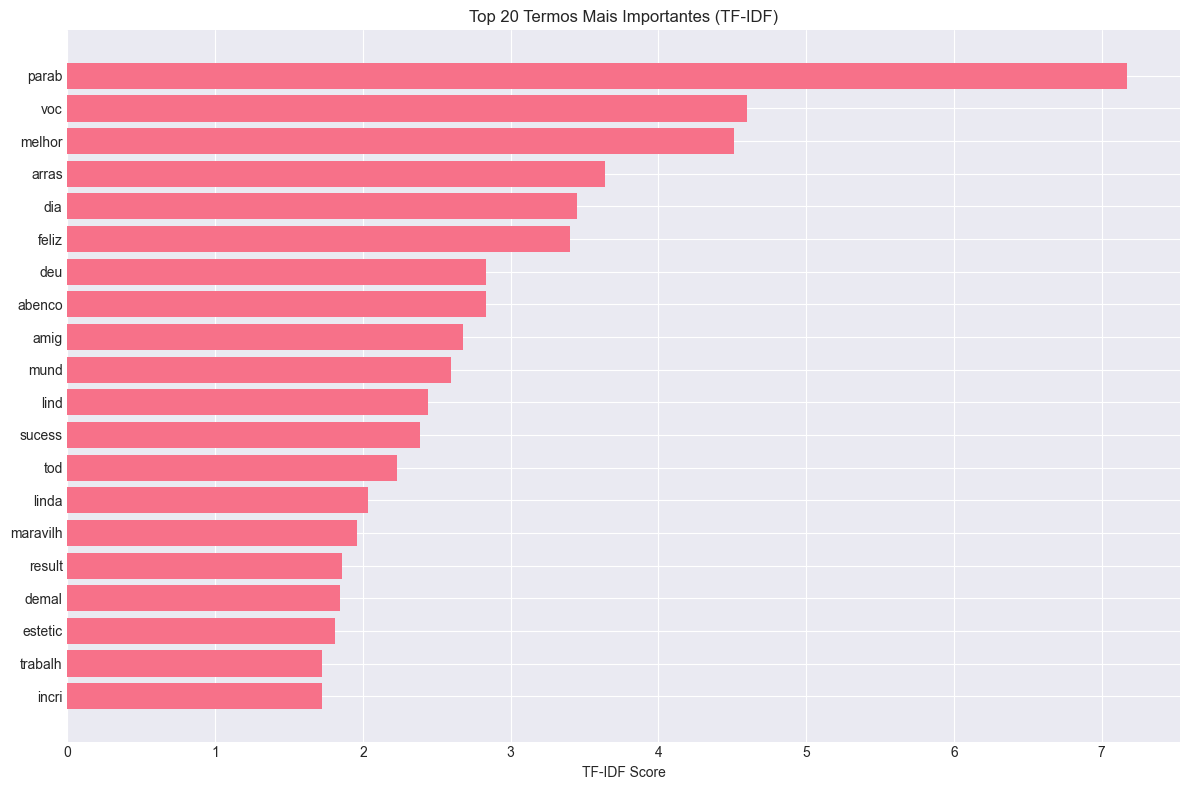

In [15]:

# ----------------------------------------
# 7.1 TF-IDF
# ----------------------------------------
print("\n" + "-"*70)
print("1️⃣ TF-IDF - TERMOS MAIS IMPORTANTES")
print("-"*70)

vectorizer_tfidf = TfidfVectorizer(max_features=30, min_df=2)
tfidf_matrix = vectorizer_tfidf.fit_transform(textos_validos)
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

print(f"\n🔑 Top 30 termos mais importantes (TF-IDF):")
for i, palavra in enumerate(feature_names_tfidf, 1):
    print(f"   {i:2d}. {palavra}")

# Visualização TF-IDF
plt.figure(figsize=(12, 8))
scores = tfidf_matrix.sum(axis=0).A1
indices_top = np.argsort(scores)[-20:][::-1]
top_palavras = [feature_names_tfidf[i] for i in indices_top]
top_scores = [scores[i] for i in indices_top]

plt.barh(range(len(top_palavras)), top_scores)
plt.yticks(range(len(top_palavras)), top_palavras)
plt.xlabel('TF-IDF Score')
plt.title('Top 20 Termos Mais Importantes (TF-IDF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('dados/results/tfidf_top_termos.png', dpi=300, bbox_inches='tight')
print(f"✅ Gráfico TF-IDF salvo")



----------------------------------------------------------------------
2️⃣ ANÁLISE DE SENTIMENTO
----------------------------------------------------------------------

😊 DISTRIBUIÇÃO DE SENTIMENTOS:
   Neutro: 56 (100.0%)
✅ Gráfico de sentimento salvo


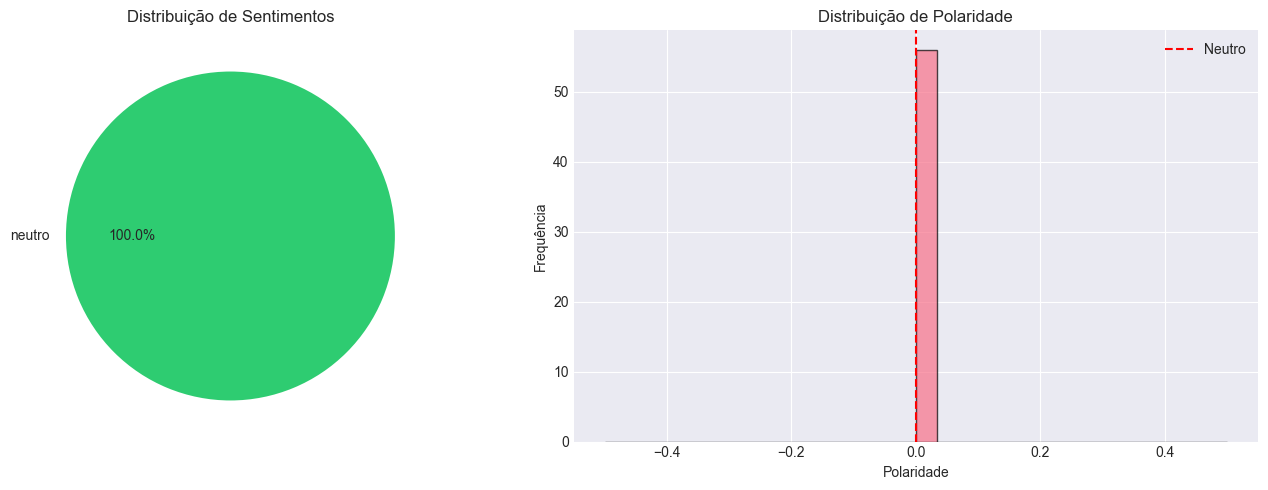

In [16]:

# ----------------------------------------
# 7.2 ANÁLISE DE SENTIMENTO
# ----------------------------------------
print("\n" + "-"*70)
print("2️⃣ ANÁLISE DE SENTIMENTO")
print("-"*70)

def analisar_sentimento(texto):
    """Classifica sentimento do texto"""
    if not texto or len(texto.strip()) == 0:
        return 'neutro', 0.0
    
    try:
        blob = TextBlob(texto)
        polaridade = blob.sentiment.polarity
        
        if polaridade > 0.1:
            return 'positivo', polaridade
        elif polaridade < -0.1:
            return 'negativo', polaridade
        else:
            return 'neutro', polaridade
    except:
        return 'neutro', 0.0

sentimentos = []
polaridades = []

for texto_orig in textos_originais:
    sent, pol = analisar_sentimento(texto_orig)
    sentimentos.append(sent)
    polaridades.append(pol)

# Estatísticas
sent_counter = Counter(sentimentos)
print(f"\n😊 DISTRIBUIÇÃO DE SENTIMENTOS:")
for sent, count in sent_counter.items():
    porcentagem = (count / len(sentimentos)) * 100
    print(f"   {sent.capitalize()}: {count} ({porcentagem:.1f}%)")

# Visualização Sentimentos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza
axes[0].pie(sent_counter.values(), labels=sent_counter.keys(), autopct='%1.1f%%',
            colors=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[0].set_title('Distribuição de Sentimentos')

# Histograma de polaridade
axes[1].hist(polaridades, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Neutro')
axes[1].set_xlabel('Polaridade')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Polaridade')
axes[1].legend()

plt.tight_layout()
plt.savefig('dados/results/analise_sentimento.png', dpi=300, bbox_inches='tight')
print(f"✅ Gráfico de sentimento salvo")


In [17]:

# ----------------------------------------
# 7.3 CLUSTERING
# ----------------------------------------
print("\n" + "-"*70)
print("3️⃣ CLUSTERING (K-MEANS)")
print("-"*70)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

cluster_counter = Counter(clusters)
print(f"\n📦 DISTRIBUIÇÃO POR CLUSTER:")
for cluster_id in range(n_clusters):
    count = cluster_counter[cluster_id]
    porcentagem = (count / len(clusters)) * 100
    print(f"   Cluster {cluster_id}: {count} comentários ({porcentagem:.1f}%)")

# Mostrar exemplos de cada cluster
print(f"\n📝 EXEMPLOS DE CADA CLUSTER:")
for cluster_id in range(n_clusters):
    indices_cluster = [i for i, c in enumerate(clusters) if c == cluster_id]
    if indices_cluster:
        # Pegar exemplo mais próximo do centróide
        idx_exemplo = indices_cluster[0]
        idx_real = indices_validos[idx_exemplo]
        exemplo = textos_originais[idx_real][:100]
        print(f"\n   Cluster {cluster_id}: '{exemplo}...'")




----------------------------------------------------------------------
3️⃣ CLUSTERING (K-MEANS)
----------------------------------------------------------------------

📦 DISTRIBUIÇÃO POR CLUSTER:
   Cluster 0: 40 comentários (78.4%)
   Cluster 1: 6 comentários (11.8%)
   Cluster 2: 5 comentários (9.8%)

📝 EXEMPLOS DE CADA CLUSTER:

   Cluster 0: 'Ameeiiii...'

   Cluster 1: 'A melhor 😍❤️...'

   Cluster 2: 'Feliz dia para a maior que temosssss 🔥❤️...'



----------------------------------------------------------------------
4️⃣ WORD CLOUD
----------------------------------------------------------------------
✅ Word Cloud salva


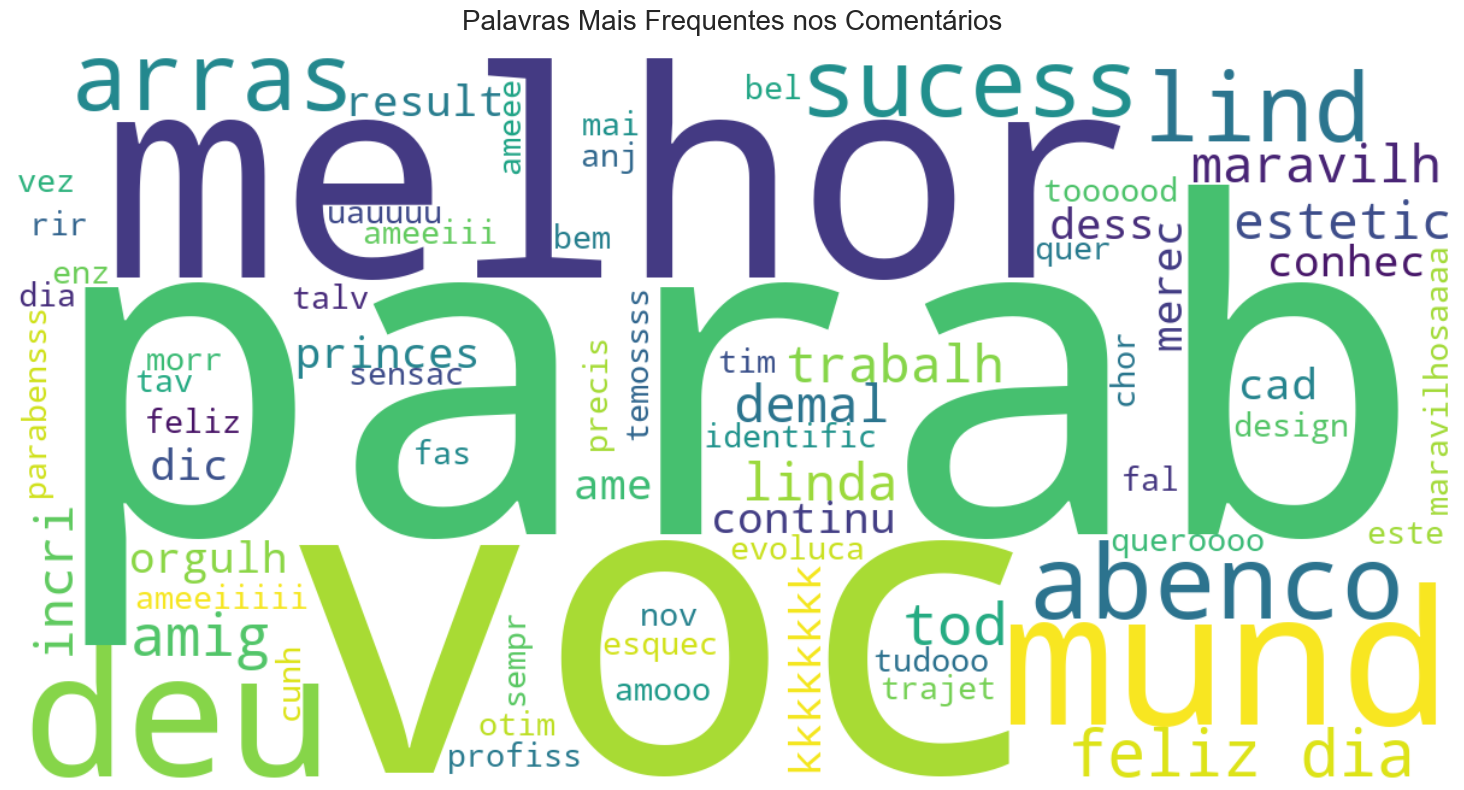

In [18]:
print("\n" + "-"*70)
print("4️⃣ WORD CLOUD")
print("-"*70)

texto_completo = ' '.join(textos_validos)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5
).generate(texto_completo)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes nos Comentários', fontsize=20, pad=20)
plt.tight_layout()
plt.savefig('dados/results/wordcloud.png', dpi=300, bbox_inches='tight')
print(f"✅ Word Cloud salva")


In [19]:
print("\n" + "-"*70)
print("5️⃣ TOPIC MODELING (LDA)")
print("-"*70)

n_topics = 3
vectorizer_count = CountVectorizer(max_features=50, min_df=2)
doc_term_matrix = vectorizer_count.fit_transform(textos_validos)
feature_names_lda = vectorizer_count.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(doc_term_matrix)

print(f"\n📚 {n_topics} TÓPICOS IDENTIFICADOS:")
n_top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names_lda[i] for i in top_indices]
    print(f"\n   Tópico {topic_idx}: {', '.join(top_words)}")

# ==========


----------------------------------------------------------------------
5️⃣ TOPIC MODELING (LDA)
----------------------------------------------------------------------

📚 3 TÓPICOS IDENTIFICADOS:

   Tópico 0: voc, parab, arras, amig, linda, demal, mund, sucess, merec, orgulh

   Tópico 1: abenco, deu, parab, lind, tod, sucess, continu, ame, dic, kkkkkkkk

   Tópico 2: melhor, feliz, dia, estetic, incri, trabalh, dess, conhec, mund, tod


In [20]:

print("\n" + "="*70)
print("📈 ETAPA 8: RESUMO DOS RESULTADOS")
print("="*70)

# Criar DataFrame com todos os resultados
df_resultados = pd.DataFrame({
    'comment_text_original': textos_originais,
    'comment_text_processed': [textos_processados[i] if i < len(textos_processados) else '' 
                               for i in range(len(textos_originais))],
    'num_palavras': [len(t.split()) for t in textos_sem_emoji],
    'num_emojis': emojis_contagem,
    'sentimento': sentimentos,
    'polaridade': polaridades
})

# Adicionar clusters (só para os válidos)
df_resultados['cluster'] = -1
for i, idx in enumerate(indices_validos):
    df_resultados.loc[idx, 'cluster'] = clusters[i]

print(f"\n📊 ESTATÍSTICAS FINAIS:")
print(f"   • Total de comentários analisados: {len(df_resultados)}")
print(f"   • Média de palavras por comentário: {df_resultados['num_palavras'].mean():.1f}")
print(f"   • Média de emojis por comentário: {df_resultados['num_emojis'].mean():.2f}")
print(f"   • Sentimento predominante: {sent_counter.most_common(1)[0][0]}")
print(f"   • Comentários positivos: {sent_counter['positivo']} ({sent_counter['positivo']/len(sentimentos)*100:.1f}%)")
print(f"   • Comentários negativos: {sent_counter['negativo']} ({sent_counter['negativo']/len(sentimentos)*100:.1f}%)")

# Salvar resultados finais
df_resultados.to_csv('dados/results/analise_completa.csv', index=False)
print(f"\n✅ Resultados completos salvos em: dados/results/analise_completa.csv")

# Criar relatório resumido
relatorio = {
    'total_comentarios': len(df_resultados),
    'media_palavras': df_resultados['num_palavras'].mean(),
    'total_emojis': total_emojis,
    'emojis_unicos': emojis_unicos,
    'top_5_emojis': top_emojis[:5],
    'sentimento_positivo_pct': (sent_counter['positivo']/len(sentimentos)*100),
    'sentimento_negativo_pct': (sent_counter['negativo']/len(sentimentos)*100),
    'sentimento_neutro_pct': (sent_counter['neutro']/len(sentimentos)*100),
    'top_10_termos_tfidf': list(feature_names_tfidf[:10]),
    'num_clusters': n_clusters,
    'num_topicos': n_topics
}

import json
with open('dados/results/relatorio_resumido.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, indent=4, ensure_ascii=False)

print("\n" + "="*70)
print("✨ ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*70)
print("\n📁 Arquivos gerados:")
print("   • dados/trusted/dataset_processado.csv")
print("   • dados/results/analise_emojis.png")
print("   • dados/results/analise_emojis_detalhada.csv")
print("   • dados/results/tfidf_top_termos.png")
print("   • dados/results/analise_sentimento.png")
print("   • dados/results/wordcloud.png")
print("   • dados/results/analise_completa.csv")
print("   • dados/results/relatorio_resumido.json")
print("="*70)


📈 ETAPA 8: RESUMO DOS RESULTADOS

📊 ESTATÍSTICAS FINAIS:
   • Total de comentários analisados: 56
   • Média de palavras por comentário: 4.3
   • Média de emojis por comentário: 1.48
   • Sentimento predominante: neutro
   • Comentários positivos: 0 (0.0%)
   • Comentários negativos: 0 (0.0%)

✅ Resultados completos salvos em: dados/results/analise_completa.csv

✨ ANÁLISE CONCLUÍDA COM SUCESSO!

📁 Arquivos gerados:
   • dados/trusted/dataset_processado.csv
   • dados/results/analise_emojis.png
   • dados/results/analise_emojis_detalhada.csv
   • dados/results/tfidf_top_termos.png
   • dados/results/analise_sentimento.png
   • dados/results/wordcloud.png
   • dados/results/analise_completa.csv
   • dados/results/relatorio_resumido.json
